# Skenario 3 — Perbandingan Model 1 (Full COA / Random Init) vs Model 2 (Greedy Init)
### Penjadwalan Mata Kuliah dengan Coati Optimization Algorithm (COA)


**Yang dibandingkan (dan catatannya):**
- **Fitness & penalty akhir** — bisa dibandingkan, namun Model 2 memiliki constraint tambahan **H7 (dosen tidak berminat)** yang tidak ada di Model 2, sehingga penalti Model 1 dapat lebih tinggi karena sumber pelanggaran ekstra. Perbandingan tetap dilakukan, dengan catatan ini.
- **Execution time** — dapat dibandingkan langsung (adil).
- **Feasible rate** — dapat dibandingkan, dengan catatan definisi feasible Model 1 lebih ketat (H7 juga harus nol).
- **Constraint bersama (H1–H6, S1)** — perbandingan paling adil karena ada di kedua model.
- **Kurva konvergensi** — fitness terbaik vs iterasi untuk kedua model.

**Yang TIDAK dibandingkan:** `reduction_pct` (hanya ada di Model 2, karena Model 1 tak punya baseline greedy).

## 1. Imports & Konfigurasi Path

Memuat pustaka dan menetapkan lokasi folder hasil kedua model serta folder output Skenario 3. **Sesuaikan `BASE_DIR` bila lokasi Anda berbeda.**

In [1]:
# Pustaka analisis & visualisasi
import os                          # susun path & cek keberadaan file
import pandas as pd               # baca CSV hasil & susun tabel perbandingan
import numpy as np                # operasi numerik
import matplotlib.pyplot as plt   # visualisasi perbandingan
from scipy import stats           # uji statistik (Wilcoxon) antar-model
from IPython.display import display

# Folder induk tempat kedua model menyimpan hasil
BASE_DIR = r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen"

# Folder hasil masing-masing model
DIR_M1 = os.path.join(BASE_DIR, "Model1")   # hasil Model 1 (Full COA random init)
DIR_M2 = os.path.join(BASE_DIR, "Model2")   # hasil Model 2 (greedy init)

# Folder output Skenario 3 (dibuat bila belum ada)
OUT_DIR = os.path.join(BASE_DIR, "Skenario 3")
os.makedirs(OUT_DIR, exist_ok=True)

def out_path(fname):
    return os.path.join(OUT_DIR, fname)

print("Folder Model 1 :", DIR_M1)
print("Folder Model 2 :", DIR_M2)
print("Output Skenario 3:", OUT_DIR)

Folder Model 1 : D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model1
Folder Model 2 : D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model2
Output Skenario 3: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Skenario 3


## 2. Membaca Hasil Kedua Model

Membaca `detail_per_run.csv` dari kedua folder. Ditambahkan kolom `model` sebagai penanda, lalu digabung untuk analisis. Bila salah satu file tidak ada, notebook memberi tahu agar model tersebut dijalankan dulu.

In [2]:
# Path file detail per-run kedua model
csv_m1 = os.path.join(DIR_M1, "detail_per_run.csv")
csv_m2 = os.path.join(DIR_M2, "detail_per_run.csv")

# Pastikan kedua file ada
for path, nama in [(csv_m1, "Model 1"), (csv_m2, "Model 2")]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File hasil {nama} tidak ditemukan: {path}\n"
            f"Jalankan notebook {nama} sampai selesai terlebih dahulu.")

# Baca & beri penanda model
df_m1 = pd.read_csv(csv_m1); df_m1['model'] = 'Model 1 (Full COA)'
df_m2 = pd.read_csv(csv_m2); df_m2['model'] = 'Model 2 (Greedy)'

# Gabung (kolom yang berbeda otomatis diisi NaN, mis. H7 hanya di Model 2, reduction hanya di Model 1)
df_all = pd.concat([df_m1, df_m2], ignore_index=True, sort=False).fillna(0)

print(f"Model 1: {len(df_m1)} run")
print(f"Model 2: {len(df_m2)} run")
print(f"Kolom gabungan: {list(df_all.columns)}")
display(df_all.head())

Model 1: 40 run
Model 2: 40 run
Kolom gabungan: ['population', 'max_iter', 'seed', 'slot_interval', 'move_frac', 'W_HEAVY', 'W_SOFT', 'MAX_MENIT_DOSEN', 'final_fitness', 'final_penalty', 'execution_time', 'is_feasible', 'H1_room_conflict', 'H2_lecturer_conflict', 'H3_lecturer_overload', 'H4_room_type_mismatch', 'H5_lunch_break', 'H6_class_completeness', 'H7_lecturer_not_interested', 'S1_floor_movement', 'model', 'initial_penalty', 'reduction_pct']


,population,max_iter,seed,slot_interval,move_frac,W_HEAVY,W_SOFT,MAX_MENIT_DOSEN,final_fitness,final_penalty,...,H2_lecturer_conflict,H3_lecturer_overload,H4_room_type_mismatch,H5_lunch_break,H6_class_completeness,H7_lecturer_not_interested,S1_floor_movement,model,initial_penalty,reduction_pct
0,30,100,0,50,1.0,1000,10,2400,159750,159750,...,0,2,0,135,0,18.0,475,Model 1 (Full COA),0.0,0.0
1,30,100,1,50,1.0,1000,10,2400,158710,158710,...,0,11,0,126,0,17.0,471,Model 1 (Full COA),0.0,0.0
2,30,100,42,50,1.0,1000,10,2400,159470,159470,...,0,0,0,133,0,22.0,447,Model 1 (Full COA),0.0,0.0
3,30,100,123,50,1.0,1000,10,2400,161450,161450,...,0,11,0,128,0,18.0,445,Model 1 (Full COA),0.0,0.0
4,30,100,2024,50,1.0,1000,10,2400,159740,159740,...,0,0,0,132,0,23.0,474,Model 1 (Full COA),0.0,0.0


## 3. Tabel Perbandingan Ringkas (per kombinasi parameter)

Merata-ratakan metrik utama per kombinasi `(population, max_iter, slot_interval)` untuk tiap model, lalu menyandingkannya berdampingan. Ini tabel inti Skenario 3.

In [3]:
# Agregasi per (model, kombinasi parameter)
grp_cols = ['model', 'population', 'max_iter', 'slot_interval']
agg = (df_all.groupby(grp_cols)
       .agg(mean_fitness=('final_fitness', 'mean'),
            std_fitness =('final_fitness', 'std'),
            best_fitness=('final_fitness', 'min'),   # terbaik = penalty terendah
            mean_penalty=('final_penalty', 'mean'),
            mean_exec_time=('execution_time', 'mean'),
            feasible_rate=('is_feasible', lambda s: (s==True).mean()*100 if s.dtype==bool else (s.astype(str)=='True').mean()*100))
       .reset_index())

# Simpan tabel perbandingan
tabel_csv = out_path("skenario3_tabel_perbandingan.csv")
agg.to_csv(tabel_csv, index=False)
print("Tabel perbandingan tersimpan:", tabel_csv)
display(agg)

Tabel perbandingan tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Skenario 3\skenario3_tabel_perbandingan.csv


,model,population,max_iter,slot_interval,mean_fitness,std_fitness,best_fitness,mean_penalty,mean_exec_time,feasible_rate
0,Model 1 (Full COA),30,100,50,159824.0,1002.835979,158710,159824.0,269.774,0.0
1,Model 1 (Full COA),30,300,50,152916.0,3112.479719,147670,152916.0,711.050,0.0
2,Model 1 (Full COA),30,500,50,149054.0,3727.912284,146540,149054.0,1202.672,0.0
3,Model 1 (Full COA),30,1000,50,145618.0,1166.970437,144540,145618.0,2177.892,0.0
4,Model 1 (Full COA),50,100,50,157946.0,5437.272294,149530,157946.0,372.200,0.0
5,Model 1 (Full COA),50,300,50,150672.0,1722.881308,149530,150672.0,1091.450,0.0
6,Model 1 (Full COA),50,500,50,146370.0,3893.738563,141500,146370.0,1798.926,0.0
7,Model 1 (Full COA),50,1000,50,143072.0,1959.826523,140860,143072.0,3815.846,0.0
8,Model 2 (Greedy),30,100,50,250278.0,2569.955253,247830,250278.0,333.716,0.0
9,Model 2 (Greedy),30,300,50,246746.0,1640.313994,244710,246746.0,946.732,0.0


## 4. Perbandingan Keseluruhan (rata-rata semua run)

Ringkasan satu baris per model: rata-rata fitness, penalty, execution time, dan feasible rate lintas seluruh run. Memberi gambaran cepat model mana yang unggul secara umum.

In [4]:
# Fungsi bantu feasible rate (kolom is_feasible bisa bool atau string)
def feas_rate(s):
    if s.dtype == bool:
        return s.mean()*100
    return (s.astype(str)=='True').mean()*100

# Ringkasan per model
overall = df_all.groupby('model').agg(
    n_run=('final_fitness', 'size'),
    mean_fitness=('final_fitness', 'mean'),
    std_fitness=('final_fitness', 'std'),
    best_fitness=('final_fitness', 'min'),   # terbaik = penalty terendah
    mean_penalty=('final_penalty', 'mean'),
    min_penalty=('final_penalty', 'min'),
    mean_exec_time=('execution_time', 'mean'),
).reset_index()
overall['feasible_rate_%'] = df_all.groupby('model')['is_feasible'].apply(feas_rate).values

overall_csv = out_path("skenario3_ringkasan_keseluruhan.csv")
overall.to_csv(overall_csv, index=False)
print("Ringkasan keseluruhan tersimpan:", overall_csv)
display(overall)

Ringkasan keseluruhan tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Skenario 3\skenario3_ringkasan_keseluruhan.csv


,model,n_run,mean_fitness,std_fitness,best_fitness,mean_penalty,min_penalty,mean_exec_time,feasible_rate_%
0,Model 1 (Full COA),40,150684.00,6285.126847,140860,150684.00,140860,1429.97625,0.0
1,Model 2 (Greedy),40,246111.25,3042.572450,241730,246111.25,241730,1848.92500,0.0


## 5. Visualisasi 1 — Distribusi Fitness Akhir per Model

Boxplot fitness akhir kedua model. Menunjukkan model mana yang cenderung menghasilkan solusi lebih baik dan lebih konsisten (kotak lebih tinggi & sempit = lebih baik & stabil).

C:\Users\ASUS\AppData\Local\Temp\ipykernel_43960\2918754868.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Model 1\n(Full COA)', 'Model 2\n(Greedy)'])


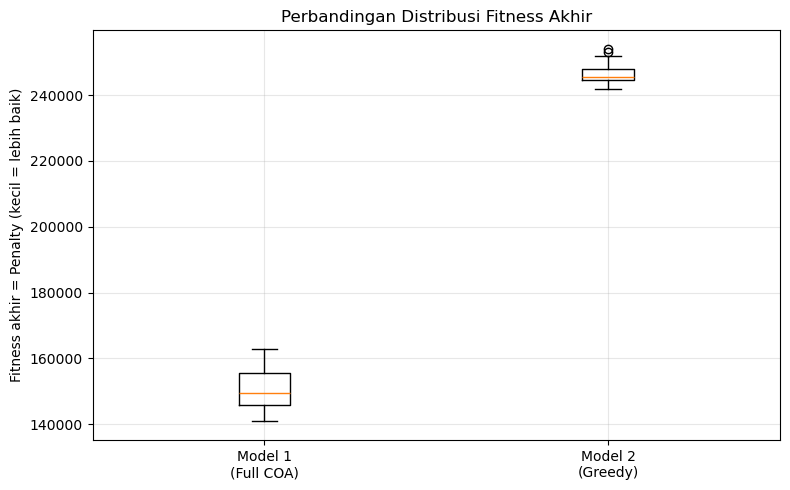

In [5]:
plt.figure(figsize=(8, 5))
data = [df_m1['final_fitness'].values, df_m2['final_fitness'].values]
plt.boxplot(data, labels=['Model 1\n(Full COA)', 'Model 2\n(Greedy)'])
plt.ylabel("Fitness akhir = Penalty (kecil = lebih baik)")
plt.title("Perbandingan Distribusi Fitness Akhir")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_path("skenario3_boxplot_fitness.png"), dpi=150)
plt.show()

## 6. Visualisasi 2 — Perbandingan Berpasangan per Konfigurasi

Untuk tiap kombinasi parameter yang sama, sandingkan mean fitness Model 1 vs Model 2. Garis penghubung menunjukkan arah keunggulan tiap konfigurasi (naik/turun antar model).

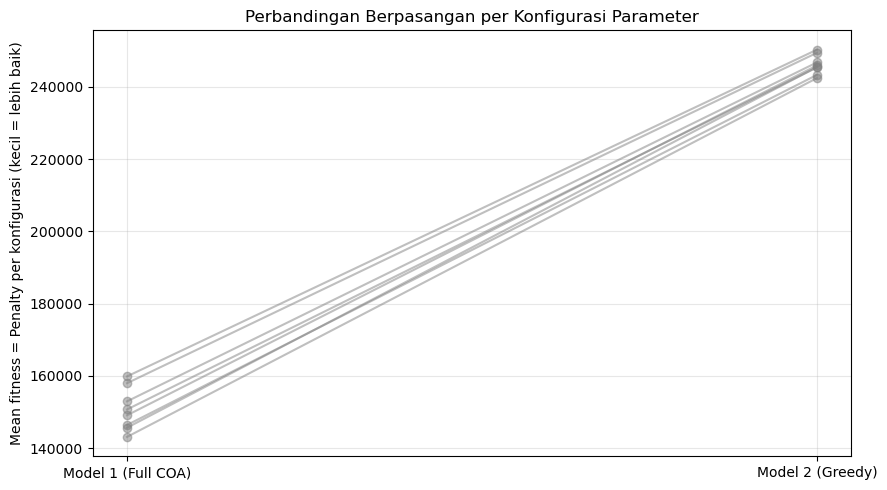

In [6]:
# Rata-rata fitness per (kombinasi) tiap model, lalu sandingkan
piv = (df_all.groupby(['population','max_iter','slot_interval','model'])['final_fitness']
       .mean().reset_index())
# Bentuk lebar: satu baris per kombinasi, kolom per model
wide = piv.pivot_table(index=['population','max_iter','slot_interval'],
                       columns='model', values='final_fitness').reset_index()

col_m1 = 'Model 1 (Full COA)'
col_m2 = 'Model 2 (Greedy)'

plt.figure(figsize=(9, 5))
for _, r in wide.iterrows():
    # garis penghubung tiap konfigurasi
    plt.plot([0, 1], [r[col_m1], r[col_m2]], color='gray', alpha=0.5, marker='o')
plt.xticks([0, 1], [ 'Model 1 (Full COA)', 'Model 2 (Greedy)' ])
plt.ylabel("Mean fitness = Penalty per konfigurasi (kecil = lebih baik)")
plt.title("Perbandingan Berpasangan per Konfigurasi Parameter")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_path("skenario3_paired_fitness.png"), dpi=150)
plt.show()

## 7. Visualisasi 3 — Perbandingan Execution Time

Boxplot waktu komputasi kedua model. Perbandingan ini adil karena tidak dipengaruhi perbedaan constraint.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_43960\2064027792.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Model 1\n(Full COA)', 'Model 2\n(Greedy)'])


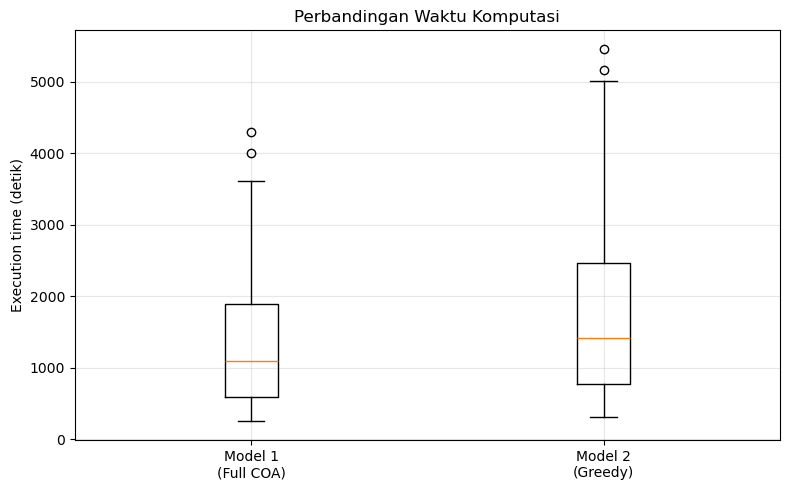

In [7]:
plt.figure(figsize=(8, 5))
data = [df_m1['execution_time'].values, df_m2['execution_time'].values]
plt.boxplot(data, labels=['Model 1\n(Full COA)', 'Model 2\n(Greedy)'])
plt.ylabel("Execution time (detik)")
plt.title("Perbandingan Waktu Komputasi")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_path("skenario3_boxplot_exectime.png"), dpi=150)
plt.show()

## 8. Visualisasi 4 — Constraint Bersama (H1–H6, S1)

Perbandingan **paling adil**: rata-rata pelanggaran tiap constraint yang ada di **kedua** model. H7 (khusus Model 1) tidak disertakan di sini karena tidak diperlukan di Model 2.

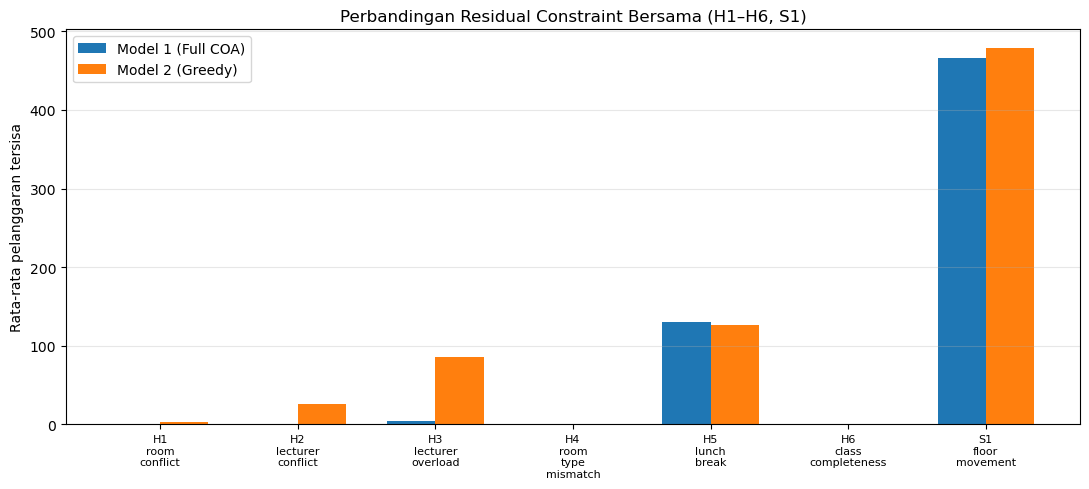

In [8]:
# Constraint yang ada di KEDUA model (penomoran berurutan)
shared = ['H1_room_conflict', 'H2_lecturer_conflict', 'H3_lecturer_overload',
          'H4_room_type_mismatch', 'H5_lunch_break', 'H6_class_completeness',
          'S1_floor_movement']
# Pakai hanya yang benar-benar ada di kedua dataframe
shared = [c for c in shared if c in df_m1.columns and c in df_m2.columns]

# Rata-rata residual tiap constraint per model
res_m1 = [df_m1[c].mean() for c in shared]
res_m2 = [df_m2[c].mean() for c in shared]

x = np.arange(len(shared)); w = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w/2, res_m1, w, label='Model 1 (Full COA)')
plt.bar(x + w/2, res_m2, w, label='Model 2 (Greedy)')
plt.xticks(x, [c.replace('_', '\n') for c in shared], fontsize=8)
plt.ylabel("Rata-rata pelanggaran tersisa")
plt.title("Perbandingan Residual Constraint Bersama (H1–H6, S1)")
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(out_path("skenario3_constraint_bersama.png"), dpi=150)
plt.show()

## 9. Visualisasi 5 — Kurva Konvergensi Terbaik Kedua Model

Membaca checkpoint konvergensi run terbaik masing-masing model dan menggambar penurunan penalty vs iterasi berdampingan. Menunjukkan model mana yang konvergen lebih cepat / ke titik lebih baik.

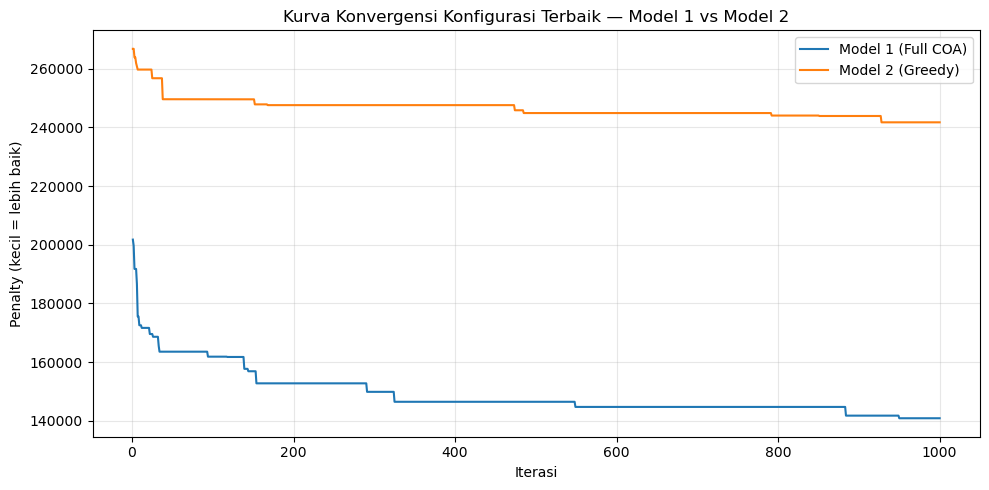

Model 1 (Full COA): pop=50, iter=1000, int=50
Model 2 (Greedy): pop=50, iter=1000, int=50


In [9]:
def kurva_terbaik(df_model, folder, label, warna):
    # Cari run dgn fitness akhir tertinggi
    r = df_model.loc[df_model['final_fitness'].idxmin()]  # terbaik = penalty terendah
    fpath = os.path.join(folder,
        f"konvergensi_pop{int(r['population'])}_iter{int(r['max_iter'])}"
        f"_int{int(r['slot_interval'])}_seed{int(r['seed'])}.csv")
    if os.path.exists(fpath):
        cv = pd.read_csv(fpath)
        plt.plot(cv['iterasi'], cv['penalty'], label=label, color=warna)
        return f"{label}: pop={int(r['population'])}, iter={int(r['max_iter'])}, int={int(r['slot_interval'])}"
    return f"{label}: file konvergensi tak ditemukan"

plt.figure(figsize=(10, 5))
info1 = kurva_terbaik(df_m1, DIR_M1, 'Model 1 (Full COA)', 'C0')
info2 = kurva_terbaik(df_m2, DIR_M2, 'Model 2 (Greedy)', 'C1')
plt.xlabel("Iterasi"); plt.ylabel("Penalty (kecil = lebih baik)")
plt.title("Kurva Konvergensi Konfigurasi Terbaik — Model 1 vs Model 2")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_path("skenario3_konvergensi.png"), dpi=150)
plt.show()
print(info1); print(info2)

## 10. Uji Statistik (Wilcoxon Signed-Rank)

Menguji apakah perbedaan fitness kedua model **signifikan secara statistik**. Karena tiap konfigurasi dijalankan pada kedua model dengan parameter sama, digunakan uji berpasangan (Wilcoxon signed-rank) pada mean fitness per konfigurasi. p-value < 0,05 berarti perbedaan signifikan.

In [10]:
# Ambil mean fitness per konfigurasi untuk kedua model (berpasangan)
wide_test = wide.dropna(subset=[col_m1, col_m2])

if len(wide_test) >= 5:
    stat, pval = stats.wilcoxon(wide_test[col_m1], wide_test[col_m2])
    print(f"Uji Wilcoxon Signed-Rank (n={len(wide_test)} konfigurasi):")
    print(f"  statistik = {stat:.4f}")
    print(f"  p-value   = {pval:.6f}")
    if pval < 0.05:
        menang = col_m1 if wide_test[col_m1].mean() > wide_test[col_m2].mean() else col_m2
        print(f"  -> Perbedaan SIGNIFIKAN (p<0.05). Rata-rata lebih tinggi: {menang}")
    else:
        print("  -> Perbedaan TIDAK signifikan (p>=0.05).")
else:
    print(f"Jumlah konfigurasi berpasangan ({len(wide_test)}) < 5; uji Wilcoxon kurang bermakna. "
          "Tambah konfigurasi/seed untuk uji yang lebih kuat.")

Uji Wilcoxon Signed-Rank (n=8 konfigurasi):
  statistik = 0.0000
  p-value   = 0.007812
  -> Perbedaan SIGNIFIKAN (p<0.05). Rata-rata lebih tinggi: Model 2 (Greedy)


## 11. Laporan Ringkas Skenario 3

Menuliskan kesimpulan naratif perbandingan ke file teks, dengan catatan penting soal ketidaksetaraan (H7 & penanganan dosen).

In [11]:
lines = []
lines.append("=== SKENARIO 3: PERBANDINGAN MODEL 1 (FULL COA) vs MODEL 2 (GREEDY) ===\n")
for _, r in overall.iterrows():
    lines.append(f"{r['model']}:")
    lines.append(f"  Mean fitness   : {r['mean_fitness']:.8f} (std {r['std_fitness']:.8f})")
    lines.append(f"  Best fitness   : {r['best_fitness']:.8f}")
    lines.append(f"  Mean penalty   : {r['mean_penalty']:.1f}  (min {r['min_penalty']:.0f})")
    lines.append(f"  Mean exec time : {r['mean_exec_time']:.2f} s")
    lines.append(f"  Feasible rate  : {r['feasible_rate_%']:.1f}%\n")

# Tentukan model unggul berdasar mean fitness
m1_fit = overall.loc[overall['model']=='Model 1 (Full COA)', 'mean_fitness'].values[0]
m2_fit = overall.loc[overall['model']=='Model 2 (Greedy)', 'mean_fitness'].values[0]
unggul = "Model 1 (Full COA)" if m1_fit < m2_fit else "Model 2 (Greedy)"  # fitness=penalty, kecil=lebih baik
lines.append(f"KESIMPULAN: rata-rata fitness (penalty) lebih rendah pada {unggul}.")
lines.append("\nCATATAN PENTING:")
lines.append("- Model 2 memiliki constraint tambahan H7 (dosen tidak berminat) yang tidak ada di Model 1,")
lines.append("  sehingga penalti Model 2 dapat lebih tinggi karena sumber pelanggaran ekstra.")
lines.append("- Perbedaan kedua model mencakup DUA faktor: strategi inisialisasi (greedy vs acak)")
lines.append("  DAN penanganan dosen (fix vs variabel COA). Interpretasi harus menyebut keduanya.")

report = out_path("skenario3_laporan.txt")
with open(report, 'w') as f:
    f.write("\n".join(lines))
print("\n".join(lines))
print("\nLaporan tersimpan:", report)

=== SKENARIO 3: PERBANDINGAN MODEL 1 (FULL COA) vs MODEL 2 (GREEDY) ===

Model 1 (Full COA):
  Mean fitness   : 150684.00000000 (std 6285.12684734)
  Best fitness   : 140860.00000000
  Mean penalty   : 150684.0  (min 140860)
  Mean exec time : 1429.98 s
  Feasible rate  : 0.0%

Model 2 (Greedy):
  Mean fitness   : 246111.25000000 (std 3042.57245031)
  Best fitness   : 241730.00000000
  Mean penalty   : 246111.2  (min 241730)
  Mean exec time : 1848.92 s
  Feasible rate  : 0.0%

KESIMPULAN: rata-rata fitness (penalty) lebih rendah pada Model 1 (Full COA).

CATATAN PENTING:
- Model 2 memiliki constraint tambahan H7 (dosen tidak berminat) yang tidak ada di Model 1,
  sehingga penalti Model 2 dapat lebih tinggi karena sumber pelanggaran ekstra.
- Perbedaan kedua model mencakup DUA faktor: strategi inisialisasi (greedy vs acak)
  DAN penanganan dosen (fix vs variabel COA). Interpretasi harus menyebut keduanya.

Laporan tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Cour

## 12. Tabel Fitness & Runtime

In [12]:
# =============================================================================
# TABEL BEST-PER-RUN PERBANDINGAN (MODEL 1 vs MODEL 2) → EXCEL
# Menyandingkan Best Fitness & Execution Time kedua model per run yang sama,
# dengan sub-kolom Model 1 / Model 2 (header dua baris / merged cell).
# =============================================================================
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

# Kunci penggabungan: kombinasi parameter + seed yang sama di kedua model
_keys = ['population', 'max_iter', 'seed', 'slot_interval']

# Gabung hasil kedua model berdasar run yang identik parameternya
_m = pd.merge(
    df_m1[_keys + ['final_fitness', 'execution_time']],
    df_m2[_keys + ['final_fitness', 'execution_time']],
    on=_keys, suffixes=('_m1', '_m2')
).sort_values(_keys).reset_index(drop=True)

# Bentuk Excel dengan header dua baris + merged
_wb = Workbook(); _ws = _wb.active; _ws.title = "Best_Per_Run"
_navy  = PatternFill('solid', fgColor='1F3864')
_white = Font(color='FFFFFF', bold=True)
_thin  = Side(style='thin', color='999999')
_border= Border(_thin, _thin, _thin, _thin)
_center= Alignment(horizontal='center', vertical='center', wrap_text=True)

# Baris 1-2: kolom identitas di-merge vertikal; Fitness & Exec Time di-merge horizontal
_ws.merge_cells('A1:A2'); _ws['A1'] = 'Population\n(n_pop)'
_ws.merge_cells('B1:B2'); _ws['B1'] = 'Iteration\n(max_iter)'
_ws.merge_cells('C1:C2'); _ws['C1'] = 'Seed'
_ws.merge_cells('D1:D2'); _ws['D1'] = 'Interval'
_ws.merge_cells('E1:F1'); _ws['E1'] = 'Best Fitness'      # membentang 2 kolom
_ws['E2'] = 'Model 1'; _ws['F2'] = 'Model 2'
_ws.merge_cells('G1:H1'); _ws['G1'] = 'Execution Time'    # membentang 2 kolom
_ws['G2'] = 'Model 1'; _ws['H2'] = 'Model 2'
# Format semua sel header
for _col in 'ABCDEFGH':
    for _rr in [1, 2]:
        _c = _ws[f'{_col}{_rr}']
        _c.fill = _navy; _c.font = _white; _c.alignment = _center; _c.border = _border

# Isi data mulai baris 3
_r = 3
for _, _row in _m.iterrows():
    _ws.cell(_r, 1, int(_row['population'])).alignment = _center
    _ws.cell(_r, 2, int(_row['max_iter'])).alignment = _center
    _ws.cell(_r, 3, int(_row['seed'])).alignment = _center
    _ws.cell(_r, 4, int(_row['slot_interval'])).alignment = _center
    _ws.cell(_r, 5, f"{_row['final_fitness_m1']:.8f}").alignment = _center   # fitness M1
    _ws.cell(_r, 6, f"{_row['final_fitness_m2']:.8f}").alignment = _center   # fitness M2
    _ws.cell(_r, 7, f"{_row['execution_time_m1']}s").alignment = _center     # waktu M1
    _ws.cell(_r, 8, f"{_row['execution_time_m2']}s").alignment = _center     # waktu M2
    for _col in 'ABCDEFGH':
        _ws[f'{_col}{_r}'].border = _border
    _r += 1

# Lebar kolom
for _col, _w in zip('ABCDEFGH', [13, 13, 7, 9, 13, 13, 13, 13]):
    _ws.column_dimensions[_col].width = _w

# Simpan
_XLSX = out_path("skenario3_best_per_run.xlsx")
_wb.save(_XLSX)
print("Tabel perbandingan best-per-run tersimpan:", _XLSX)
display(_m.head(10))

Tabel perbandingan best-per-run tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Skenario 3\skenario3_best_per_run.xlsx


,population,max_iter,seed,slot_interval,final_fitness_m1,execution_time_m1,final_fitness_m2,execution_time_m2
0,30,100,0,50,159750,288.57,251820,357.14
1,30,100,1,50,158710,272.90,247830,340.43
2,30,100,42,50,159470,264.94,248970,340.36
3,30,100,123,50,161450,273.23,254020,315.45
4,30,100,2024,50,159740,249.23,248750,315.20
5,30,300,0,50,155520,728.45,245640,932.66
6,30,300,1,50,153810,724.93,247830,976.43
7,30,300,42,50,154820,762.20,248800,874.94
8,30,300,123,50,152760,678.74,246750,901.47
9,30,300,2024,50,147670,660.93,244710,1048.16
